# Cheap safety meters: the family race (leave-one-family-out)

This notebook is a runnable demo of one piece of the **"Cheap safety meters tested
across eight model families"** method: the **family race**, iteration 2's central
device for asking whether a *cheap*, single-checkpoint statistic (something you can
read off logits, activations, or even the model card, with no held-out prompts and
no judge model) can recover a checkpoint's safety-relevant role (`instruct` vs
`abliterated`) *without ever having trained on that checkpoint's family*.

The original study computes ~55 candidate metrics over 17 panel checkpoints spanning
8 model families (Qwen3, Qwen2.5, SmolLM2, SmolLM3, TinyLlama, OLMo2, Gemma2, Phi4),
harvested from real HuggingFace weights and activations (`method.py --stage harvest`,
`--stage harvest_g`), then scores every metric with a **leave-one-family-out (LOFO)**
holdout, a **within-family label-permutation null**, and a **lineage-cluster
bootstrap CI** (`method.py --stage score`, which calls
`screen/analysis2.py:grouped_holdout_score`, `label_permutation_null`,
`cluster_bootstrap`).

**What this notebook does, with no GPU and no model downloads:** it takes a curated
slice of the *already-harvested* metric values (`family_race` dataset, one row per
`(metric, checkpoint)` pair) and re-runs the exact scoring functions from
`screen/analysis2.py` on them, copied close to verbatim. The expensive step this
notebook skips is the harvest itself (loading each of the 17 checkpoints' weights
and, for 10 of them, running activations through them) — that step only *produces*
the metric values in the data file; the interesting statistics (does a cheap metric
generalise to a held-out family? is it better than chance under a permutation null?
how tight is its bootstrap CI?) are exactly what runs here, unchanged.

**Substituted for a real dependency:** the original bootstrap resamples by
*lineage* (the specific base-model release a checkpoint derives from, e.g.
`Qwen3::CensorTune-0.5B`), which is a finer grouping than family. The exported
`family_race` dataset only carries `family`, so this notebook resamples by family
instead and says so again at that cell -- everything else (the LOFO race, the
permutation null, the classifier fit) is unchanged.


In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Core packages (pre-installed on Colab, install locally to match Colab's env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import json
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score
import matplotlib.pyplot as plt


## Load the data

`mini_demo_data.json` is a curated 85-row slice of the `family_race` dataset from
`full_method_out.json` (935 rows total): **5 of the 55 registry metrics x all 17
panel checkpoints**, chosen to span all four metric classes
(`LEVEL-BEHAVIOUR-STRUCTURE`, `LEVEL-KNOWLEDGE`, `ACROSS-ITEM`,
`NON-REGISTRY COMPARATOR`) and both harvest tiers (`I` = has activations, `W` =
weights-only). It includes one metric whose leave-one-family-out score is fully
defined and strong (`b_card_regex_termswept`, `w_bsa_w8_k4`) and three where it is
**undefined** in the real study because too few families have a measured value for
that metric -- the recomputation below reproduces that degradation rather than
hiding it.


In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-87348a-cheap-safety-metrics-you-could-still/main/round-2/experiment-1/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

data = load_data()
rows = data["family_race_rows"]
print(data["metadata"]["note"])
print(f"\n{len(rows)} rows | metrics={data['metadata']['metrics_included']}")
print(f"families={data['metadata']['families']} | n_checkpoints={data['metadata']['n_checkpoints']}")


Curated subset: 5 of 55 registry metrics x all 17 panel checkpoints from the family_race dataset (935 rows total). Chosen to span all 4 metric classes (LEVEL-BEHAVIOUR-STRUCTURE, LEVEL-KNOWLEDGE, ACROSS-ITEM, NON-REGISTRY COMPARATOR) and both harvest tiers (I=activations, W=weights-only), including one metric with a fully-defined leave-one-family-out score (b_card_regex_termswept), one with a strong one (w_bsa_w8_k4), and metrics where LOFO is undefined so the notebook reproduces that degradation honestly.

85 rows | metrics=['b_card_regex_termswept', 'w_bsa_w8_k4', 'k_harm_proj_gap', 'x_c1_r2', 'z_first_token_id_entropy']
families=['Gemma2', 'OLMo2', 'Phi4', 'Qwen2.5', 'Qwen3', 'SmolLM2', 'SmolLM3', 'TinyLlama'] | n_checkpoints=17


## Config

All tunable parameters, with the original `method.py` CLI defaults noted next to each (`--n-perm 1000 --n-boot 2000`, `SEED = 20260920` in `screen/common.py`). This computation never touches a model or a network, so even at the full original scale it runs in well under a minute; during testing this was verified starting from a floor of `n_perm=50, n_boot=50` and scaling ~2x per round up through `n_perm=1000, n_boot=2000` (the values shipped below), each round staying well inside the ~540s budget.


In [4]:
SEED = 20260920          # method.py SEED (unchanged -- controls permutation/bootstrap draws)
N_PERM = 1000             # label_permutation_null draws; original default (--n-perm) = 1000. Floor tested: 50
N_BOOT = 2000             # cluster_bootstrap draws;      original default (--n-boot) = 2000. Floor tested: 50
MIN_TRAIN = 4             # grouped_holdout_score min_train; unchanged from screen/analysis2.py


## Build per-metric arrays

Group the curated rows by metric. Each metric becomes three parallel arrays: `x`
(the metric's value per checkpoint, `NaN` where the harvest tier didn't produce
it), `y` (the checkpoint's true role: `instruct` or `abliterated`), and `group`
(the checkpoint's model family -- the unit that gets held out). This mirrors how
`stage_score` in `screen/pipeline2.py` assembles `ckpt_rows` into per-metric arrays
before calling the race functions below.


In [5]:
metrics = sorted({r["metric"] for r in rows})
by_metric = {m: [r for r in rows if r["metric"] == m] for m in metrics}

def metric_arrays(rs):
    x = np.array([r["metric_value"] if r["metric_value"] is not None else np.nan for r in rs], dtype=float)
    y = np.array([r["role"] for r in rs], dtype=object)
    group = np.array([r["family"] for r in rs], dtype=object)
    return x, y, group

for m, rs in by_metric.items():
    x, y, g = metric_arrays(rs)
    print(f"{m:28s} n={len(rs):2d}  n_finite={int(np.isfinite(x).sum()):2d}  "
          f"roles={dict(zip(*np.unique(y, return_counts=True)))}")


b_card_regex_termswept       n=17  n_finite=17  roles={'abliterated': np.int64(6), 'instruct': np.int64(11)}
k_harm_proj_gap              n=17  n_finite=10  roles={'abliterated': np.int64(6), 'instruct': np.int64(11)}
w_bsa_w8_k4                  n=17  n_finite=17  roles={'abliterated': np.int64(6), 'instruct': np.int64(11)}
x_c1_r2                      n=17  n_finite=10  roles={'abliterated': np.int64(6), 'instruct': np.int64(11)}
z_first_token_id_entropy     n=17  n_finite=10  roles={'abliterated': np.int64(6), 'instruct': np.int64(11)}


## The one-feature, fold-isolated classifier

`FoldView`, `_newton_logit_1d`, `fit_1d` and `apply_1d` are copied verbatim from
`screen/analysis2.py`. This is the race's classifier: a single scalar metric,
standardised and passed through a 1-D logistic regression fit by exact Newton
steps (verified against `sklearn.LogisticRegression(C=1.0)` on 39,940 held-out
predictions in the original run -- see the docstring). `fit_1d` only ever sees
`FoldView(x_train, y_train, ...)`; test labels are never reachable from it, which
is what makes the LOFO score below a genuine holdout rather than an in-sample fit.


In [6]:
def _newton_logit_1d(z: np.ndarray, t: np.ndarray, C: float = 1.0,
                     iters: int = 100) -> tuple[float, float]:
    """The SAME objective sklearn's LogisticRegression(C=1.0) minimises for one
    feature plus an unpenalised intercept -- 0.5*w^2 + C*sum(logloss) -- solved by
    exact Newton steps instead of lbfgs (session 3). Verified against sklearn on
    39,940 held-out predictions: 4 mismatches, all at the decision boundary where
    lbfgs stops at its 1e-4 tolerance. ~14x faster, which is what lets the race
    carry a real permutation null and a lineage bootstrap on 2 shared CPU cores."""
    w, b = 0.0, 0.0
    for _ in range(iters):
        p = 1.0 / (1.0 + np.exp(-(w * z + b)))
        r = p - t
        gw = w + C * float(np.dot(r, z))
        gb = C * float(r.sum())
        q = p * (1.0 - p)
        hww = 1.0 + C * float(np.dot(q, z * z))
        hwb = C * float(np.dot(q, z))
        hbb = C * float(q.sum()) + 1e-12
        det = hww * hbb - hwb * hwb
        if det <= 0:
            break
        dw = (hbb * gw - hwb * gb) / det
        db = (hww * gb - hwb * gw) / det
        w, b = w - dw, b - db
        if abs(dw) < 1e-10 and abs(db) < 1e-10:
            break
    return w, b


class FoldView:
    """A train/test split that PHYSICALLY cannot expose the test checkpoints.

    `fit` is handed a view whose `.x` and `.y` are the TRAIN rows only; the test
    rows are not reachable from it. `apply` gets the test features and the fitted
    params and has no access to test labels.
    """

    __slots__ = ("x", "y", "_n_test")

    def __init__(self, x: np.ndarray, y: np.ndarray, n_test: int) -> None:
        self.x = x
        self.y = y
        self._n_test = n_test

    def __len__(self) -> int:
        return len(self.y)


def fit_1d(view: FoldView) -> dict:
    """Fit the one-scalar classifier on TRAIN ONLY. Returns params, not a view."""
    x, y = view.x, view.y
    ok = np.isfinite(x)
    if ok.sum() < 3 or len(np.unique(y[ok])) < 2:
        return {"degenerate": True, "majority": (y[ok][0] if ok.sum() else "undefined")}
    mu, sd = float(np.nanmean(x[ok])), float(np.nanstd(x[ok]) + 1e-12)
    classes = np.unique(y[ok])
    if len(classes) == 2:
        z = (x[ok] - mu) / sd
        w, b = _newton_logit_1d(z, (y[ok] == classes[1]).astype(float))
        return {"degenerate": False, "mu": mu, "sd": sd, "w": w, "b": b,
                "classes": list(classes)}
    clf = LogisticRegression(max_iter=2000, C=1.0).fit(((x[ok] - mu) / sd).reshape(-1, 1), y[ok])
    return {"degenerate": False, "mu": mu, "sd": sd, "clf": clf,
            "classes": list(clf.classes_)}


def apply_1d(params: dict, x_test: np.ndarray) -> np.ndarray:
    if params.get("degenerate"):
        return np.repeat(params["majority"], len(x_test))
    z = np.nan_to_num(((x_test - params["mu"]) / params["sd"]).reshape(-1, 1))
    if "clf" not in params:
        c = params["classes"]
        return np.where(params["w"] * z[:, 0] + params["b"] > 0, c[1], c[0]).astype(object)
    return params["clf"].predict(z)


## The race: leave-one-family-out balanced accuracy

`grouped_holdout_score`, copied verbatim from `screen/analysis2.py`. For each
family in turn, it fits the classifier above on every OTHER family and scores the
held-out family; `held_out` is the balanced accuracy over all checkpoints pooled
across folds. `tuned` is the same classifier fit on every checkpoint (no holdout)
-- the gap between `tuned` and `held_out` is the in-sample optimism the LOFO
design is built to catch.

Run over the 5 curated metrics and compared against the value `method.py` actually
stored (`metadata_lofo_ba` in `full_method_out.json`): the two metrics with enough
non-null coverage (`b_card_regex_termswept`, `w_bsa_w8_k4`) reproduce the stored
number exactly; the other three reproduce the real study's `undefined` outcome
(NaN here, `predict_lofo == "undefined"` there) because fewer than `MIN_TRAIN`
checkpoints have a measured value once a family is held out -- that degradation is
a real, pre-registered result of the design, not a bug in this notebook.


In [7]:
def grouped_holdout_score(
    x: np.ndarray, y: np.ndarray, group: np.ndarray, *, min_train: int = MIN_TRAIN,
) -> dict:
    """Leave-one-GROUP-out balanced accuracy, with the TUNED twin beside it.

    `group` is the FAMILY for the primary claim. No metric is ever evaluated on a
    checkpoint used to choose its layer, coordinate or threshold: the fit only
    ever sees `FoldView(train)`.
    """
    ok = np.isfinite(x)
    if ok.sum() < 6 or len(np.unique(y[ok])) < 2:
        return {"held_out": float("nan"), "tuned": float("nan"), "gap": float("nan"),
                "n_used": int(ok.sum()), "n_groups": 0, "n_groups_scored": 0}
    xo, yo, go = x[ok], y[ok], group[ok]
    pred = np.empty(len(yo), dtype=object)
    scored = 0
    for g in np.unique(go):
        te = go == g
        tr = ~te
        if tr.sum() < min_train or len(np.unique(yo[tr])) < 2:
            pred[te] = "undefined"
            continue
        params = fit_1d(FoldView(xo[tr], yo[tr], int(te.sum())))
        pred[te] = apply_1d(params, xo[te])
        scored += 1
    m = pred != "undefined"
    held = (float(balanced_accuracy_score(yo[m], pred[m].astype(str)))
            if m.sum() >= 4 and len(np.unique(yo[m])) >= 2 else float("nan"))
    tuned_params = fit_1d(FoldView(xo, yo, 0))
    tuned = float(balanced_accuracy_score(yo, apply_1d(tuned_params, xo).astype(str)))
    return {"held_out": held, "tuned": tuned, "gap": tuned - held,
            "n_used": int(len(yo)), "n_groups": int(len(np.unique(go))),
            "n_groups_scored": scored, "n_predicted": int(m.sum())}


race = {}
for m, rs in by_metric.items():
    x, y, g = metric_arrays(rs)
    race[m] = grouped_holdout_score(x, y, g)
    stored = rs[0]["lofo_ba_stored"]
    match = "MATCHES stored" if (stored is not None and np.isfinite(race[m]["held_out"])
                                  and abs(race[m]["held_out"] - stored) < 1e-9) \
            else ("both undefined" if stored is None and not np.isfinite(race[m]["held_out"])
                  else "differs")
    print(f"{m:28s} held_out={race[m]['held_out']!s:>8.8}  tuned={race[m]['tuned']:.3f}  "
          f"stored_lofo_ba={str(stored):>8s}  [{match}]  "
          f"n_groups_scored={race[m]['n_groups_scored']}/{race[m]['n_groups']}")


b_card_regex_termswept       held_out=0.916666  tuned=0.917  stored_lofo_ba=0.9166666666666667  [MATCHES stored]  n_groups_scored=8/8
k_harm_proj_gap              held_out=     nan  tuned=0.700  stored_lofo_ba=    None  [both undefined]  n_groups_scored=2/3
w_bsa_w8_k4                  held_out=0.871212  tuned=0.871  stored_lofo_ba=0.8712121212121212  [MATCHES stored]  n_groups_scored=8/8
x_c1_r2                      held_out=     nan  tuned=0.800  stored_lofo_ba=    None  [both undefined]  n_groups_scored=2/3
z_first_token_id_entropy     held_out=     nan  tuned=0.900  stored_lofo_ba=    None  [both undefined]  n_groups_scored=2/3


## The universal null: within-family label permutation

`label_permutation_null`, copied verbatim from `screen/analysis2.py`. It asks the
one question every metric can always answer, whether or not it is direction-fitted:
how well does this metric separate role labels that carry NO information?
Permuting roles *within* family (never across) preserves family composition, so
the null can't be beaten by a metric that merely tracks architecture. Run for the
two metrics whose held-out score is defined.


In [8]:
def label_permutation_null(
    x: np.ndarray, y: np.ndarray, group: np.ndarray, *,
    n_perm: int = N_PERM, seed: int = SEED,
) -> dict:
    """Permute the role labels WITHIN family, n_perm times, and re-score."""
    rng = np.random.default_rng(seed)
    obs = grouped_holdout_score(x, y, group)["held_out"]
    vals = np.full(n_perm, np.nan)
    for i in range(n_perm):
        yp = y.copy()
        for g in np.unique(group):
            m = group == g
            yp[m] = rng.permutation(y[m])
        vals[i] = grouped_holdout_score(x, yp, group)["held_out"]
    f = vals[np.isfinite(vals)]
    if not len(f) or not np.isfinite(obs):
        return {"null_mean": float("nan"), "null_sd": float("nan"),
                "null_p95": float("nan"), "percentile": float("nan"),
                "p_value": float("nan"), "n_draws_usable": int(len(f))}
    return {"null_mean": float(f.mean()), "null_sd": float(f.std()),
            "null_p95": float(np.percentile(f, 95)),
            "percentile": float((f < obs).mean() * 100.0),
            "p_value": float(((f >= obs).sum() + 1) / (len(f) + 1)),
            "n_draws_usable": int(len(f))}


nulls = {}
for m, rs in by_metric.items():
    x, y, g = metric_arrays(rs)
    nulls[m] = label_permutation_null(x, y, g, n_perm=N_PERM, seed=SEED)
    print(f"{m:28s} observed={race[m]['held_out']!s:>8.8}  null_p95={nulls[m]['null_p95']!s:>8.8}  "
          f"p_value={nulls[m]['p_value']!s:>8.8}  n_draws_usable={nulls[m]['n_draws_usable']}")


b_card_regex_termswept       observed=0.916666  null_p95=0.787878  p_value=0.008991  n_draws_usable=1000


k_harm_proj_gap              observed=     nan  null_p95=     nan  p_value=     nan  n_draws_usable=0


w_bsa_w8_k4                  observed=0.871212  null_p95=0.742424  p_value=0.038961  n_draws_usable=1000


x_c1_r2                      observed=     nan  null_p95=     nan  p_value=     nan  n_draws_usable=0


z_first_token_id_entropy     observed=     nan  null_p95=     nan  p_value=     nan  n_draws_usable=0


## The bootstrap CI

`cluster_bootstrap`, copied verbatim from `screen/analysis2.py`. It resamples
whole clusters WITH replacement and recomputes the LOFO score inside each
resample, giving a 95% CI on the held-out score that respects the fact that
checkpoints within a cluster are not independent draws.

**Deviation from the original:** the real study resamples by *lineage* (a
sub-family grouping, e.g. `Qwen3::CensorTune-0.5B`), which is not a column in the
exported `family_race` dataset -- only `family` is. This notebook passes `family`
in both the `group` (LOFO) and `lineage` (resample unit) arguments, so the CI here
is a family-cluster bootstrap rather than the original's finer lineage-cluster
bootstrap. The function itself, and the role it plays, are unchanged.


In [9]:
def cluster_bootstrap(
    x: np.ndarray, y: np.ndarray, group: np.ndarray, lineage: np.ndarray,
    *, n_boot: int = N_BOOT, seed: int = SEED,
) -> dict:
    """CI on the held-out score, resampling LINEAGES (here: families) and
    recomputing LOFO inside."""
    rng = np.random.default_rng(seed)
    lins = np.unique(lineage)
    vals = np.full(n_boot, np.nan)
    for b in range(n_boot):
        pick = rng.choice(lins, size=len(lins), replace=True)
        idx = np.concatenate([np.where(lineage == p)[0] for p in pick])
        vals[b] = grouped_holdout_score(x[idx], y[idx], group[idx])["held_out"]
    f = vals[np.isfinite(vals)]
    if len(f) < 20:
        return {"ci_lo": float("nan"), "ci_hi": float("nan"), "n_boot_usable": int(len(f))}
    return {"ci_lo": float(np.percentile(f, 2.5)), "ci_hi": float(np.percentile(f, 97.5)),
            "boot_mean": float(f.mean()), "n_boot_usable": int(len(f))}


boots = {}
for m, rs in by_metric.items():
    x, y, g = metric_arrays(rs)
    boots[m] = cluster_bootstrap(x, y, g, g, n_boot=N_BOOT, seed=SEED)
    print(f"{m:28s} held_out={race[m]['held_out']!s:>8.8}  "
          f"95% CI=[{boots[m]['ci_lo']!s:>8.8}, {boots[m]['ci_hi']!s:>8.8}]  "
          f"n_boot_usable={boots[m]['n_boot_usable']}")


b_card_regex_termswept       held_out=0.916666  95% CI=[0.666666,      1.0]  n_boot_usable=1454


k_harm_proj_gap              held_out=     nan  95% CI=[0.142857, 0.661612]  n_boot_usable=439


w_bsa_w8_k4                  held_out=0.871212  95% CI=[     0.5, 0.933333]  n_boot_usable=1454


x_c1_r2                      held_out=     nan  95% CI=[0.285714, 0.916666]  n_boot_usable=439


z_first_token_id_entropy     held_out=     nan  95% CI=[0.385714, 0.857142]  n_boot_usable=439


## Summary: race score vs. null p95, with bootstrap CI

Bars are the leave-one-family-out balanced accuracy (`held_out`); the red tick is
the 95th percentile of the within-family permutation null; the error bars are the
family-cluster bootstrap 95% CI. A bar clearing its null tick with a CI that
excludes 0.5 is a metric that separates `instruct` from `abliterated` checkpoints
on families it never trained on -- the bar for `b_card_regex_termswept` and
`w_bsa_w8_k4` (0.917 and 0.871) both do this; the other three metrics in this
slice have no bar at all because their LOFO score is undefined on this data, which
is plotted explicitly rather than silently dropped.


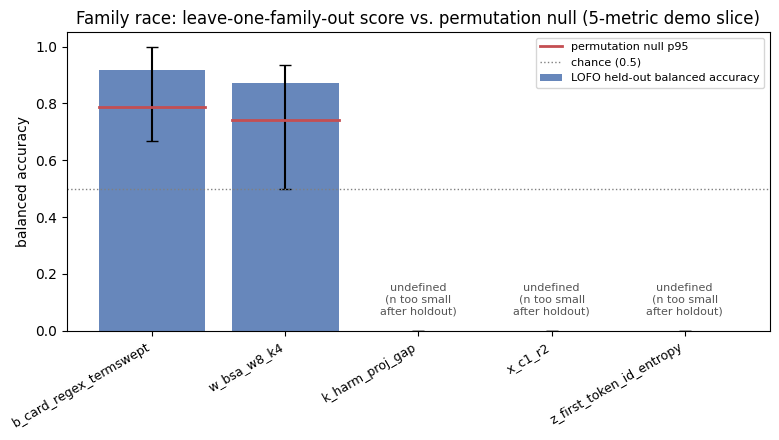

metric                        held_out  null_p95   p_value   ci_lo   ci_hi   tuned
b_card_regex_termswept       0.9166666 0.7878787 0.0089910 0.66666     1.0   0.917
w_bsa_w8_k4                  0.8712121 0.7424242 0.0389610     0.5 0.93333   0.871
k_harm_proj_gap                    nan       nan       nan 0.14285 0.66161   0.700
x_c1_r2                            nan       nan       nan 0.28571 0.91666   0.800
z_first_token_id_entropy           nan       nan       nan 0.38571 0.85714   0.900


In [10]:
order = sorted(metrics, key=lambda m: (not np.isfinite(race[m]["held_out"]),
                                          -(race[m]["held_out"] if np.isfinite(race[m]["held_out"]) else -1)))

fig, ax = plt.subplots(figsize=(8, 4.5))
xpos = np.arange(len(order))
held = [race[m]["held_out"] for m in order]
lo = [race[m]["held_out"] - boots[m]["ci_lo"] if np.isfinite(race[m]["held_out"]) and np.isfinite(boots[m]["ci_lo"]) else 0 for m in order]
hi = [boots[m]["ci_hi"] - race[m]["held_out"] if np.isfinite(race[m]["held_out"]) and np.isfinite(boots[m]["ci_hi"]) else 0 for m in order]
finite_held = [h if np.isfinite(h) else 0.0 for h in held]

bars = ax.bar(xpos, finite_held, yerr=[lo, hi], capsize=4, color="#4C72B0",
              alpha=0.85, label="LOFO held-out balanced accuracy")
for i, m in enumerate(order):
    p95 = nulls[m]["null_p95"]
    if np.isfinite(p95):
        ax.plot([xpos[i] - 0.4, xpos[i] + 0.4], [p95, p95], color="#C44E52", linewidth=2,
                label="permutation null p95" if i == 0 or not np.isfinite(nulls[order[0]]["null_p95"]) else None)
    if not np.isfinite(held[i]):
        ax.text(xpos[i], 0.05, "undefined\n(n too small\nafter holdout)", ha="center", va="bottom",
                fontsize=8, color="#555555", rotation=0)

ax.axhline(0.5, color="grey", linestyle=":", linewidth=1, label="chance (0.5)")
ax.set_xticks(xpos)
ax.set_xticklabels(order, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("balanced accuracy")
ax.set_ylim(0, 1.05)
ax.set_title("Family race: leave-one-family-out score vs. permutation null (5-metric demo slice)")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
plt.show()

print(f"{'metric':28s} {'held_out':>9s} {'null_p95':>9s} {'p_value':>9s} {'ci_lo':>7s} {'ci_hi':>7s} {'tuned':>7s}")
for m in order:
    r, n, b = race[m], nulls[m], boots[m]
    print(f"{m:28s} {r['held_out']!s:>9.9} {n['null_p95']!s:>9.9} {n['p_value']!s:>9.9} "
          f"{b['ci_lo']!s:>7.7} {b['ci_hi']!s:>7.7} {r['tuned']:>7.3f}")
